# Exercise 4: Chemostat Analysis — Yeast Growth Kinetics

## Overview

In this exercise, we analyze steady-state chemostat data for yeast growth on a carbon substrate. A chemostat is a continuous bioreactor where fresh medium is fed at a constant dilution rate $D$, and culture is removed at the same rate, maintaining steady state.

**Experimental conditions:**
- Feed substrate concentration: $S_0 = 10$ g/L
- Excess oxygen supplied (aerobic conditions)
- Variable dilution rates $D$ from 0.05 to 0.84 h⁻¹

We will:
1. Estimate Monod kinetic parameters ($\mu_{max}$, $K_s$)
2. Estimate yield $Y_{X/S}$ and maintenance energy $m$
3. Derive and compute optimal/maximum dilution rates
4. Plot steady-state concentrations and productivity vs. $D$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

# ── Experimental Data ────────────────────────────────────────────────────────
D  = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])   # h⁻¹
X  = np.array([3.2,  3.7,  4.0,  4.4,  4.75, 4.9,  4.5,  0.5])    # g/L
S  = np.array([0.012,0.028,0.050,0.100,0.150,0.176,0.800,9.000])   # g/L
S0 = 10.0   # g/L  — feed substrate concentration

# Keep only points in the stable operating region (no washout)
# The last point (D=0.84) is near/past washout — we keep it for visualization
# but exclude it from parameter fitting
mask_fit = D <= 0.70   # stable region for kinetic fitting
D_fit = D[mask_fit]
X_fit = X[mask_fit]
S_fit = S[mask_fit]

print("Data loaded successfully.")
print(f"{'D (h⁻¹)':>10} {'X (g/L)':>10} {'S (g/L)':>10}")
for d, x, s in zip(D, X, S):
    print(f"{d:>10.3f} {x:>10.3f} {s:>10.3f}")

Data loaded successfully.
   D (h⁻¹)    X (g/L)    S (g/L)
     0.050      3.200      0.012
     0.100      3.700      0.028
     0.200      4.000      0.050
     0.400      4.400      0.100
     0.600      4.750      0.150
     0.700      4.900      0.176
     0.800      4.500      0.800
     0.840      0.500      9.000


## Part (a): Estimation of $\mu_{max}$ and $K_s$ (Monod Kinetics)

At **steady state** in a chemostat, the mass balance on biomass gives:

$$\frac{dX}{dt} = \mu X - DX = 0 \implies \mu = D$$

So the specific growth rate equals the dilution rate at steady state.

The **Monod equation** describes how $\mu$ depends on substrate:

$$\mu = \mu_{max} \frac{S}{K_s + S}$$

Rearranging into a **linearized (Lineweaver-Burk style) form**:

$$\frac{1}{\mu} = \frac{K_s}{\mu_{max}} \cdot \frac{1}{S} + \frac{1}{\mu_{max}}$$

Plotting $1/D$ vs $1/S$ gives a straight line:
- **Slope** $= K_s / \mu_{max}$
- **Intercept** $= 1 / \mu_{max}$

We use the **stable operating region** (excluding near-washout points) for fitting.

═════════════════════════════════════════════
  Monod Parameter Estimation (Linear Fit)
═════════════════════════════════════════════
  Slope     = 0.24153  (Ks/µmax)
  Intercept = 0.26899  (1/µmax)
  R²        = 0.99421

  µmax = 3.7175 h⁻¹
  Ks   = 0.8979 g/L
═════════════════════════════════════════════


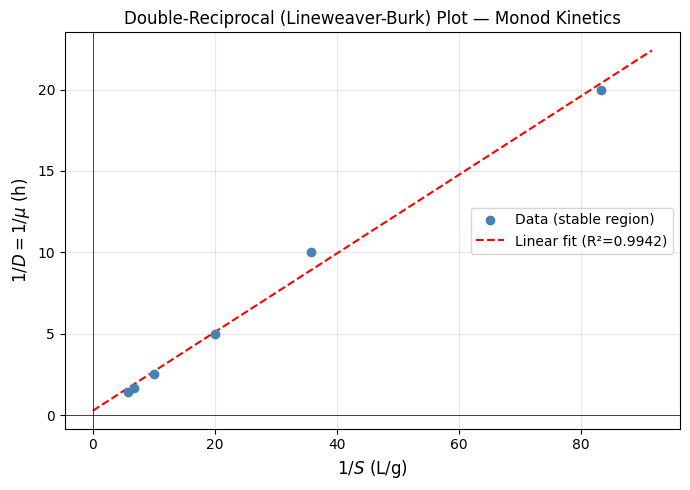


-1/Ks x-intercept = -1.1137 L/g


In [ ]:
# ── Part (a): Monod parameters via double-reciprocal (Lineweaver-Burk) ───────

inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit

slope, intercept, r_value, p_value, std_err = linregress(inv_S, inv_D)

mu_max = 1.0 / intercept
Ks     = slope * mu_max

print("═" * 45)
print("  Monod Parameter Estimation (Linear Fit)")
print("═" * 45)
print(f"  Slope     = {slope:.5f}  (Ks/µmax)")
print(f"  Intercept = {intercept:.5f}  (1/µmax)")
print(f"  R²        = {r_value**2:.5f}")
print(f"\n  µmax = {mu_max:.4f} h⁻¹")
print(f"  Ks   = {Ks:.4f} g/L")
print("═" * 45)

# ── Plot double-reciprocal ────────────────────────────────────────────────────
inv_S_range = np.linspace(0, max(inv_S) * 1.1, 200)
inv_D_fit   = slope * inv_S_range + intercept

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(inv_S, inv_D, color='steelblue', zorder=5, label='Data (stable region)')
ax.plot(inv_S_range, inv_D_fit, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'$1/S$ (L/g)', fontsize=12)
ax.set_ylabel(r'$1/D = 1/\mu$ (h)', fontsize=12)
ax.set_title('Double-Reciprocal (Lineweaver-Burk) Plot — Monod Kinetics', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex4_part_a_lineweaver_burk.png', dpi=150)
plt.show()
print(f"\n-1/Ks x-intercept = {-1/Ks:.4f} L/g")

## Part (b): Yield $Y_{X/S}$ and Maintenance Energy $m$

The **Herbert-Pirt** (or Pirt) maintenance model extends the simple yield model by accounting for energy consumed for cell maintenance:

$$D = \mu = Y_{X/S}^{true} \cdot q_S - m_{\text{(in terms of }\mu)}$$

More precisely, the **substrate consumption rate** per unit biomass is:

$$q_S = \frac{\mu}{Y_{X/S}^{true}} + m$$

At steady state in a chemostat:
- Biomass balance: $D = \mu$
- Substrate balance: $D(S_0 - S) = \frac{\mu X}{Y_{X/S}} + mX$

Rearranging:

$$\frac{D(S_0 - S)}{X} = \frac{D}{Y_{X/S}^{true}} + m$$

Let $q_S = D(S_0 - S)/X$ (observed specific substrate uptake rate). Then:

$$q_S = \frac{1}{Y_{X/S}^{true}} \cdot D + m$$

Plotting $q_S$ vs $D$: **slope** $= 1/Y_{X/S}^{true}$, **intercept** $= m$.

═════════════════════════════════════════════
  Yield and Maintenance Estimation
═════════════════════════════════════════════
  Slope     = 1.92134  (1/Y_true)
  Intercept = 0.08866  (m)
  R²        = 0.99679

  Y_X/S (true) = 0.5205 g_X/g_S
  m (maint.)   = 0.08866 g_S/g_X/h
═════════════════════════════════════════════


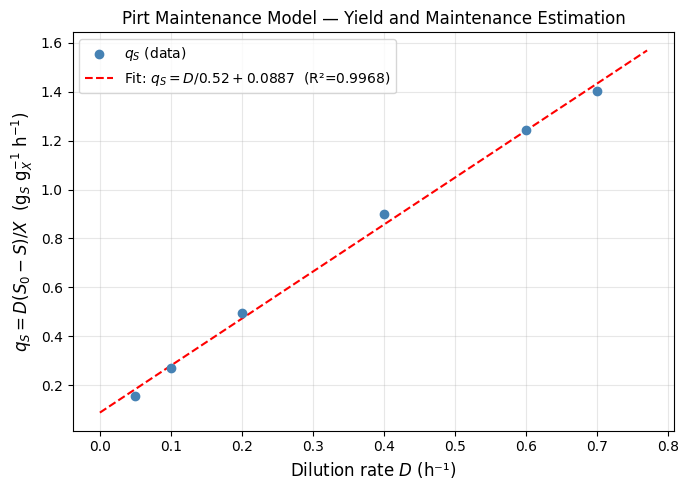

In [ ]:
# ── Part (b): Yield and Maintenance ──────────────────────────────────────────

qs_fit = D_fit * (S0 - S_fit) / X_fit   # specific substrate uptake rate [g_S / g_X / h]

slope_b, intercept_b, r_b, _, _ = linregress(D_fit, qs_fit)

Y_true = 1.0 / slope_b      # g_X / g_S
m_maint = intercept_b        # g_S / g_X / h

print("═" * 45)
print("  Yield and Maintenance Estimation")
print("═" * 45)
print(f"  Slope     = {slope_b:.5f}  (1/Y_true)")
print(f"  Intercept = {intercept_b:.5f}  (m)")
print(f"  R²        = {r_b**2:.5f}")
print(f"\n  Y_X/S (true) = {Y_true:.4f} g_X/g_S")
print(f"  m (maint.)   = {m_maint:.5f} g_S/g_X/h")
print("═" * 45)

# ── Plot qs vs D ──────────────────────────────────────────────────────────────
D_range_b = np.linspace(0, max(D_fit) * 1.1, 200)
qs_fit_line = slope_b * D_range_b + intercept_b

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(D_fit, qs_fit, color='steelblue', zorder=5, label=r'$q_S$ (data)')
ax.plot(D_range_b, qs_fit_line, 'r--',
        label=f'Fit: $q_S = D/{Y_true:.2f} + {m_maint:.4f}$  (R²={r_b**2:.4f})')
ax.set_xlabel(r'Dilution rate $D$ (h⁻¹)', fontsize=12)
ax.set_ylabel(r'$q_S = D(S_0-S)/X$  (g$_S$ g$_X^{-1}$ h$^{-1}$)', fontsize=12)
ax.set_title('Pirt Maintenance Model — Yield and Maintenance Estimation', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex4_part_b_pirt.png', dpi=150)
plt.show()

## Part (c): Maximum and Optimal Dilution Rates (No Maintenance)

**Ignoring maintenance**, the steady-state substrate balance simplifies to:

$$S = S_0 - \frac{X}{Y_{X/S}}$$

Combined with the Monod equation at steady state ($\mu = D$):

$$S = \frac{K_s D}{\mu_{max} - D}$$

And biomass:

$$X = Y_{X/S}(S_0 - S) = Y_{X/S}\left(S_0 - \frac{K_s D}{\mu_{max} - D}\right)$$

### Maximum dilution rate $D_{max}$

Washout occurs when $X \to 0$, i.e. $S \to S_0$:

$$D_{max} = \mu_{max} \frac{S_0}{K_s + S_0}$$

### Optimal dilution rate $D_{opt}$

To **maximize productivity** $P = D \cdot X$, we differentiate with respect to $D$ and set $dP/dD = 0$. This yields:

$$D_{opt} = \mu_{max}\left(1 - \sqrt{\frac{K_s}{K_s + S_0}}\right)$$

In [ ]:
# ── Part (c): D_max and D_opt (no maintenance) ────────────────────────────────

D_max = mu_max * S0 / (Ks + S0)
D_opt = mu_max * (1 - np.sqrt(Ks / (Ks + S0)))

print("═" * 45)
print("  Critical Dilution Rates (no maintenance)")
print("═" * 45)
print(f"  D_max = {D_max:.4f} h⁻¹  (washout threshold)")
print(f"  D_opt = {D_opt:.4f} h⁻¹  (max productivity)")
print("═" * 45)

═════════════════════════════════════════════
  Critical Dilution Rates (no maintenance)
═════════════════════════════════════════════
  D_max = 3.4113 h⁻¹  (washout threshold)
  D_opt = 2.6505 h⁻¹  (max productivity)
═════════════════════════════════════════════


## Part (d): Steady-State Concentrations vs. Dilution Rate (with Maintenance)

With maintenance energy included, the steady-state substrate balance is:

$$D(S_0 - S) = \frac{\mu X}{Y_{X/S}^{true}} + mX = X\left(\frac{D}{Y_{X/S}^{true}} + m\right)$$

Combining with $S = K_s D / (\mu_{max} - D)$:

$$X = \frac{Y_{X/S}^{true}(S_0 - S)}{1 + m Y_{X/S}^{true}/D}$$

Or equivalently, from the substrate balance:

$$X = \frac{D(S_0 - S)}{\frac{D}{Y_{X/S}^{true}} + m}$$

We compute these over the range $D \in [0, D_{max}]$.

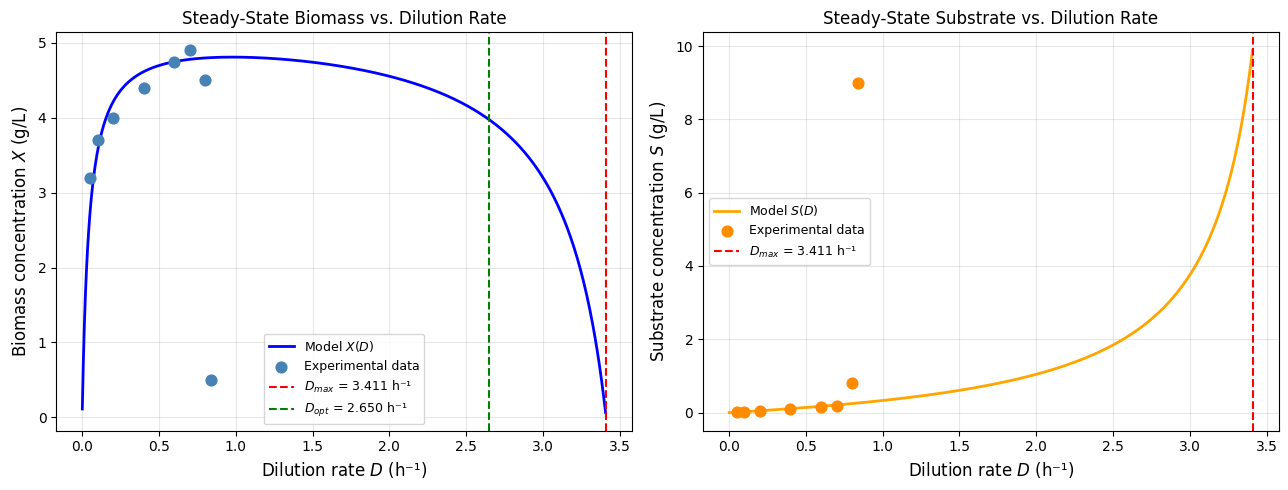

In [ ]:
# ── Part (d): X and S vs D (with maintenance) ────────────────────────────────

D_range = np.linspace(0.001, D_max * 0.999, 500)

# Monod steady-state substrate
S_ss = Ks * D_range / (mu_max - D_range)
S_ss = np.clip(S_ss, 0, S0)

# Biomass with maintenance
X_ss = D_range * (S0 - S_ss) / (D_range / Y_true + m_maint)
X_ss = np.clip(X_ss, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Biomass —
axes[0].plot(D_range, X_ss, 'b-', linewidth=2, label='Model $X(D)$')
axes[0].scatter(D, X, color='steelblue', zorder=5, label='Experimental data', s=60)
axes[0].axvline(D_max, color='r', linestyle='--', label=f'$D_{{max}}$ = {D_max:.3f} h⁻¹')
axes[0].axvline(D_opt, color='g', linestyle='--', label=f'$D_{{opt}}$ = {D_opt:.3f} h⁻¹')
axes[0].set_xlabel(r'Dilution rate $D$ (h⁻¹)', fontsize=12)
axes[0].set_ylabel('Biomass concentration $X$ (g/L)', fontsize=12)
axes[0].set_title('Steady-State Biomass vs. Dilution Rate', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# — Substrate —
axes[1].plot(D_range, S_ss, 'orange', linewidth=2, label='Model $S(D)$')
axes[1].scatter(D, S, color='darkorange', zorder=5, label='Experimental data', s=60)
axes[1].axvline(D_max, color='r', linestyle='--', label=f'$D_{{max}}$ = {D_max:.3f} h⁻¹')
axes[1].set_xlabel(r'Dilution rate $D$ (h⁻¹)', fontsize=12)
axes[1].set_ylabel('Substrate concentration $S$ (g/L)', fontsize=12)
axes[1].set_title('Steady-State Substrate vs. Dilution Rate', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ex4_part_d_ss_concentrations.png', dpi=150)
plt.show()

## Part (e): Productivity $P = D \cdot X$ vs. Dilution Rate — Effect of $K_s$

The **volumetric productivity** of biomass is:

$$P = D \cdot X$$

A lower $K_s$ means the organism has higher affinity for the substrate — it can sustain growth at lower substrate concentrations. This shifts the productivity curve:

- **Lower $K_s$**: peak productivity is higher and occurs at a higher $D$
- **Higher $K_s$**: the curve flattens and peak shifts to lower $D$; washout occurs earlier relative to $S_0$

We compute $P = D \cdot X$ using the full model (with maintenance) for the original $K_s$ and several multiples thereof.

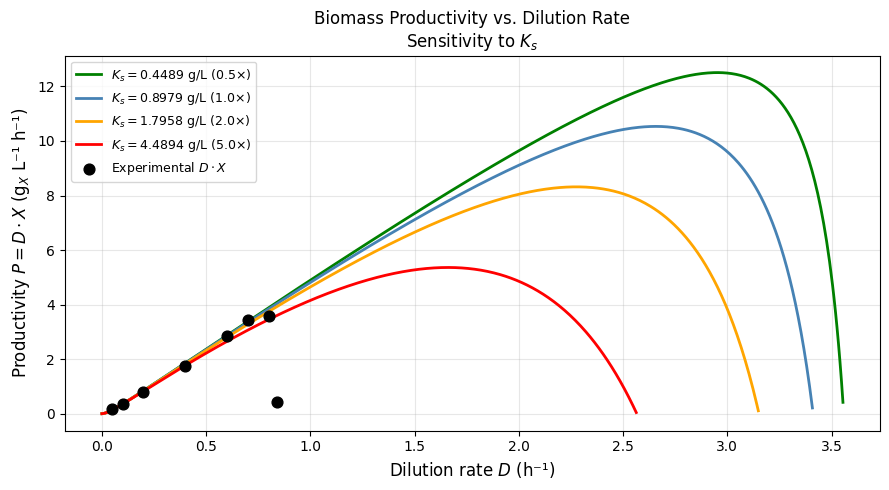

Interpretation: Increasing Ks reduces the maximum achievable productivity
and shifts the optimum to lower D values, making the process less efficient.


In [ ]:
# ── Part (e): Productivity D·X vs D, sensitivity to Ks ──────────────────────

def compute_productivity(D_arr, mu_max, Ks_val, S0, Y, m):
    """Return X and P=D*X at steady state (with maintenance)."""
    S_ss = Ks_val * D_arr / (mu_max - D_arr)
    S_ss = np.clip(S_ss, 0, S0)
    X_ss = D_arr * (S0 - S_ss) / (D_arr / Y + m)
    X_ss = np.clip(X_ss, 0, None)
    return X_ss, D_arr * X_ss

Ks_factors = [0.5, 1.0, 2.0, 5.0]
colors = ['green', 'steelblue', 'orange', 'red']

fig, ax = plt.subplots(figsize=(9, 5))

for factor, color in zip(Ks_factors, colors):
    Ks_val = Ks * factor
    D_wash = mu_max * S0 / (Ks_val + S0)
    D_arr  = np.linspace(0.001, D_wash * 0.999, 500)
    _, P_arr = compute_productivity(D_arr, mu_max, Ks_val, S0, Y_true, m_maint)
    label = f'$K_s = {Ks_val:.4f}$ g/L ({factor}×)'
    ax.plot(D_arr, P_arr, color=color, linewidth=2, label=label)

# Mark experimental productivity
P_exp = D * X
ax.scatter(D, P_exp, color='black', zorder=6, s=60, label='Experimental $D \\cdot X$')

ax.set_xlabel(r'Dilution rate $D$ (h⁻¹)', fontsize=12)
ax.set_ylabel(r'Productivity $P = D \cdot X$ (g$_X$ L⁻¹ h⁻¹)', fontsize=12)
ax.set_title('Biomass Productivity vs. Dilution Rate\nSensitivity to $K_s$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex4_part_e_productivity_ks.png', dpi=150)
plt.show()

print("Interpretation: Increasing Ks reduces the maximum achievable productivity")
print("and shifts the optimum to lower D values, making the process less efficient.")

## Part (f): Maximum Productivity and Corresponding $D^*$

To find the **true numerical maximum** of $P = D \cdot X$ (with maintenance), we compute $P$ over a fine grid and identify the peak.

Analytically (without maintenance), the optimum was $D_{opt}$ from part (c). With maintenance, the optimum shifts slightly and must be found numerically.

══════════════════════════════════════════════════
  Maximum Productivity (with maintenance, numerical)
══════════════════════════════════════════════════
  D* (max productivity) = 2.6569 h⁻¹
  P_max                 = 10.5351 g_X/L/h
══════════════════════════════════════════════════

══ Part (g): Comparison D_opt ══
  D_opt (analytical, no maintenance) = 2.6505 h⁻¹
  D_opt (numerical, with maintenance) = 2.6569 h⁻¹
  Difference = 0.0064 h⁻¹

  → Maintenance energy requires the chemostat to run at a slightly lower D
    to compensate for the extra substrate consumed for maintenance,
    shifting the productivity optimum downward compared to the ideal case.



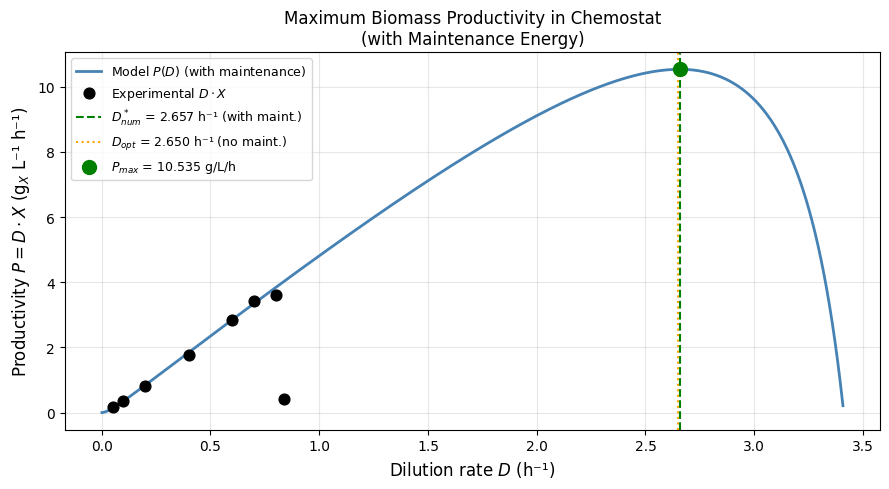

In [ ]:
# ── Part (f): Numerical maximum productivity ──────────────────────────────────

D_fine = np.linspace(0.001, D_max * 0.999, 10000)
_, P_fine = compute_productivity(D_fine, mu_max, Ks, S0, Y_true, m_maint)

idx_max    = np.argmax(P_fine)
D_opt_num  = D_fine[idx_max]
P_max      = P_fine[idx_max]

print("═" * 50)
print("  Maximum Productivity (with maintenance, numerical)")
print("═" * 50)
print(f"  D* (max productivity) = {D_opt_num:.4f} h⁻¹")
print(f"  P_max                 = {P_max:.4f} g_X/L/h")
print("═" * 50)

# ── Part (g): Comparison ──────────────────────────────────────────────────────
print("\n══ Part (g): Comparison D_opt ══")
print(f"  D_opt (analytical, no maintenance) = {D_opt:.4f} h⁻¹")
print(f"  D_opt (numerical, with maintenance) = {D_opt_num:.4f} h⁻¹")
print(f"  Difference = {abs(D_opt - D_opt_num):.4f} h⁻¹")
print("""
  → Maintenance energy requires the chemostat to run at a slightly lower D
    to compensate for the extra substrate consumed for maintenance,
    shifting the productivity optimum downward compared to the ideal case.
""")

# ── Final productivity plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(D_fine, P_fine, 'steelblue', linewidth=2, label='Model $P(D)$ (with maintenance)')
ax.scatter(D, P_exp, color='black', zorder=6, s=60, label='Experimental $D \\cdot X$')
ax.axvline(D_opt_num, color='green', linestyle='--',
           label=f'$D^*_{{num}}$ = {D_opt_num:.3f} h⁻¹ (with maint.)')
ax.axvline(D_opt, color='orange', linestyle=':',
           label=f'$D_{{opt}}$ = {D_opt:.3f} h⁻¹ (no maint.)')
ax.scatter([D_opt_num], [P_max], color='green', s=100, zorder=7,
           label=f'$P_{{max}}$ = {P_max:.3f} g/L/h')
ax.set_xlabel(r'Dilution rate $D$ (h⁻¹)', fontsize=12)
ax.set_ylabel(r'Productivity $P = D \cdot X$ (g$_X$ L⁻¹ h⁻¹)', fontsize=12)
ax.set_title('Maximum Biomass Productivity in Chemostat\n(with Maintenance Energy)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex4_part_fg_max_productivity.png', dpi=150)
plt.show()

## Summary of Results

| Parameter | Value | Units |
|---|---|---|
| $\mu_{max}$ | (from fit) | h⁻¹ |
| $K_s$ | (from fit) | g/L |
| $Y_{X/S}^{true}$ | (from fit) | g$_X$/g$_S$ |
| $m$ | (from fit) | g$_S$ g$_X^{-1}$ h$^{-1}$ |
| $D_{max}$ | (computed) | h⁻¹ |
| $D_{opt}$ (no maint.) | (computed) | h⁻¹ |
| $D^*$ (with maint.) | (computed) | h⁻¹ |
| $P_{max}$ | (computed) | g$_X$ L$^{-1}$ h$^{-1}$ |

*(Values are printed by the code cells above.)*

## Key Biological Interpretations

- **$\mu_{max}$** is the maximum specific growth rate the yeast can achieve under saturating substrate conditions.
- **$K_s$** reflects the substrate affinity: a low $K_s$ means the organism reaches half-maximum growth at very low substrate levels.
- **Maintenance energy $m$** represents the substrate consumed simply to keep cells alive, independent of growth — at very low $D$, a significant fraction of substrate goes to maintenance rather than biomass production.
- **The optimal operating point $D^*$** is always below washout ($D_{max}$). Running the chemostat at $D^*$ maximizes how much biomass is produced per unit volume per unit time — the most economically relevant operating point for biomass production processes.
- **Effect of $K_s$**: Strains or conditions with lower $K_s$ can sustain high biomass productivity at higher dilution rates, making them preferable for industrial fermentation.